In [1]:
from modeling.evaluate import _load_run
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import DictConfig, OmegaConf
from types import SimpleNamespace
import pickle


In [2]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.split import make_split
from modeling.evaluate import _load_run

In [3]:
# load the experimental config 
run_name = "ward3_negbin_glm_20221201_20231231_20260316_00e8c532"
cfg = OmegaConf.create({'load_model': run_name})
model_path, run_cfg = _load_run(cfg)

In [6]:
# get model and the feature columns
with open(model_path, "rb") as f:
    saved = pickle.load(f)
model = saved["model"]
feature_cols = saved["feature_cols"]
feat_params = SimpleNamespace(**saved["feat_params"])


In [7]:
# get the test set
pothole_df, weather_df = build_daily(run_cfg)
feat_df = assemble_features(pothole_df, weather_df, feat_params)
feat_df = make_split(feat_df, run_cfg.split)

test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"].values

In [17]:
doy = np.arctan2(feat_df["sin_doy"], feat_df["cos_doy"])
doy[doy <= 0] = doy[doy <= 0] + 2 * np.pi
doy *= 365 / (2*np.pi)

In [20]:
# now predict! 
preds = model.predict(X_test)

In [22]:
y_test

array([ 7.,  8., 20., 21., 24., 16., 28., 11.,  9., 12., 11.,  7.,  4.,
       14.,  5.,  5.,  9., 15., 14.,  1.,  2.,  3.,  0.,  1.,  5.,  3.,
        2.,  3.,  1., 10.,  5.,  5.,  0.,  0., 10., 13.,  3.,  3.,  1.,
        4.,  4.,  2.,  4.,  8.,  3.,  4.,  7.,  4.,  6.,  6.,  3.,  0.,
        4.,  3.])

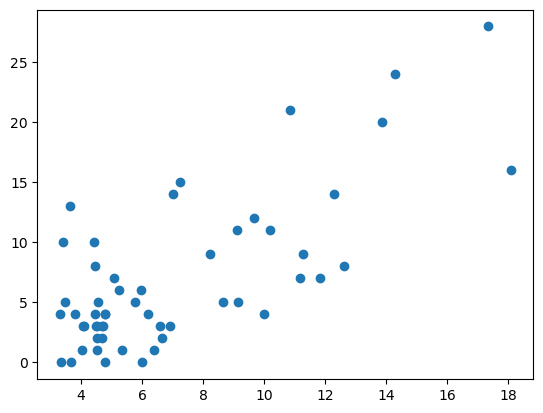

In [23]:
plt.scatter(preds, y_test)